In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData
from scipy import stats
from scipy.interpolate import interp1d


In [2]:

# Lunghezze d'onda in Å
lambda_A_list = [
    3843, 3941, 4039, 4137, 4235, 4333, 4431, 4529, 4627, 4725,
    4823, 4921, 5019, 5117, 5215, 5313, 5411, 5509, 5607, 5705,
    5807, 5909, 6011, 6113, 6215, 6317, 6419, 6521, 6623, 6725,
    6827, 6929, 7031, 7133, 7235, 7337, 7439, 7541, 7643, 7745,
    7847, 7949, 8051, 8153, 8255, 8357, 8459, 8561, 8663, 8765,
    8867, 8969, 9071, 9122, 9173, 9224, 9275, 9326, 9377, 9428,
    9479, 9530, 9581, 9632, 9683, 9734, 9785, 9836, 9887, 9938,
    9989, 10040, 10091, 10142, 10193, 10244, 10295, 10346, 10397,
    10448, 10499, 10550, 10601, 10652, 10703, 10754, 10805, 10856,
    10907, 10958, 11009, 11060, 11111, 11162, 11213, 11264, 11315,
    11366, 11417, 11468, 11519, 11570, 11621, 11672, 11723
]

# Densità di corrente J(λ) in A per unità di area
J_list = [
    3.85E-03, 6.15E-03, 1.00E-02, 1.38E-02, 1.92E-02, 2.54E-02,
    3.38E-02, 4.23E-02, 5.15E-02, 5.77E-02, 7.00E-02, 7.92E-02,
    9.08E-02, 1.05E-01, 1.18E-01, 1.35E-01, 1.48E-01, 1.68E-01,
    1.96E-01, 2.05E-01, 2.27E-01, 2.77E-01, 2.95E-01, 2.98E-01,
    3.07E-01, 3.18E-01, 3.32E-01, 3.42E-01, 3.58E-01, 3.71E-01,
    3.82E-01, 3.92E-01, 4.02E-01, 4.08E-01, 4.13E-01, 4.16E-01,
    4.16E-01, 4.12E-01, 4.30E-01, 4.91E-01, 4.55E-01, 4.16E-01,
    3.94E-01, 3.83E-01, 3.81E-01, 3.86E-01, 4.01E-01, 4.25E-01,
    4.55E-01, 4.94E-01, 5.35E-01, 5.79E-01, 6.24E-01, 6.38E-01,
    6.65E-01, 6.86E-01, 7.04E-01, 7.21E-01, 7.33E-01, 7.46E-01,
    7.59E-01, 7.69E-01, 7.85E-01, 8.68E-01, 1.05E+00, 1.30E+00,
    1.44E+00, 1.37E+00, 1.22E+00, 1.08E+00, 9.92E-01, 9.27E-01,
    8.75E-01, 8.28E-01, 7.81E-01, 7.33E-01, 6.85E-01, 6.31E-01,
    5.75E-01, 5.21E-01, 4.65E-01, 4.25E-01, 3.58E-01, 3.11E-01,
    2.75E-01, 2.44E-01, 2.16E-01, 1.92E-01, 1.68E-01, 1.46E-01,
    1.27E-01, 1.12E-01, 9.62E-02, 8.23E-02, 6.92E-02, 5.92E-02,
    4.85E-02, 4.00E-02, 3.23E-02, 2.62E-02, 1.92E-02, 1.38E-02,
    9.23E-03, 5.38E-03, 2.31E-03
]

# Potenza per unità di area P_ua(λ)
P_ua_list = [
    0.1057692308, 0.1442307692, 0.1923076923, 0.2403846154, 0.3461538462,
    0.3653846154, 0.4134615385, 0.4326923077, 0.4903846154, 0.5192307692,
    0.5480769231, 0.6057692308, 0.6346153846, 0.6923076923, 0.7307692308,
    0.7596153846, 0.7980769231, 0.8846153846, 0.9615384615, 1.0,
    1.038461538, 1.173076923, 1.192307692, 1.153846154, 1.153846154,
    1.134615385, 1.115384615, 1.153846154, 1.173076923, 1.134615385,
    1.153846154, 1.153846154, 1.153846154, 1.153846154, 1.134615385,
    1.096153846, 1.057692308, 1.038461538, 1.057692308, 1.173076923,
    1.057692308, 0.9615384615, 0.8942307692, 0.8653846154, 0.8461538462,
    0.8076923077, 0.8653846154, 0.8846153846, 0.9230769231, 0.9807692308,
    1.057692308, 1.153846154, 1.201923077, 1.230769231, 1.25,
    1.326923077, 1.307692308, 1.346153846, 1.365384615, 1.346153846,
    1.384615385, 1.403846154, 1.413461538, 1.557692308, 1.884615385,
    2.326923077, 2.576923077, 2.442307692, 2.173076923, 1.980769231,
    1.846153846, 1.769230769, 1.692307692, 1.653846154, 1.634615385,
    1.615384615, 1.596153846, 1.576923077, 1.567307692, 1.557692308,
    1.538461538, 1.557692308, 1.519230769, 1.490384615, 1.5,
    1.442307692, 1.480769231, 1.471153846, 1.461538462, 1.451923077,
    1.442307692, 1.432692308, 1.423076923, 1.442307692, 1.403846154,
    1.384615385, 1.375, 1.375, 1.375, 1.365384615,
    1.346153846, 1.336538462, 1.365384615, 1.346153846, 1.346153846
]


J_err = 1e-5
P_ua_err = 0.001
lambda_err = 5

In [3]:

df = pd.DataFrame({
    'lambda_A': lambda_A_list,
    'lambda_A_err': lambda_err,
    'J': J_list,
    'J_err': J_err,
    'P_ua': P_ua_list,
    'P_ua_err': P_ua_err
})

# Conversione λ in nm
df['lambda_nm'] = df['lambda_A'] / 10.0
df['lambda_nm_err'] = df['lambda_A_err'] / 10.0

print(f"\nStatistiche J:")
print(f"   J max = {df['J'].max():.3f}")
print(f"   J min = {df['J'].min():.3e}")
print(f"   J medio = {df['J'].mean():.3f}")
print(f"\nStatistiche P_ua:")
print(f"   P_ua max = {df['P_ua'].max():.3f}")
print(f"   P_ua min = {df['P_ua'].min():.3f}")
print(f"   P_ua medio = {df['P_ua'].mean():.3f}")


Statistiche J:
   J max = 1.440
   J min = 2.310e-03
   J medio = 0.394

Statistiche P_ua:
   P_ua max = 2.577
   P_ua min = 0.106
   P_ua medio = 1.204


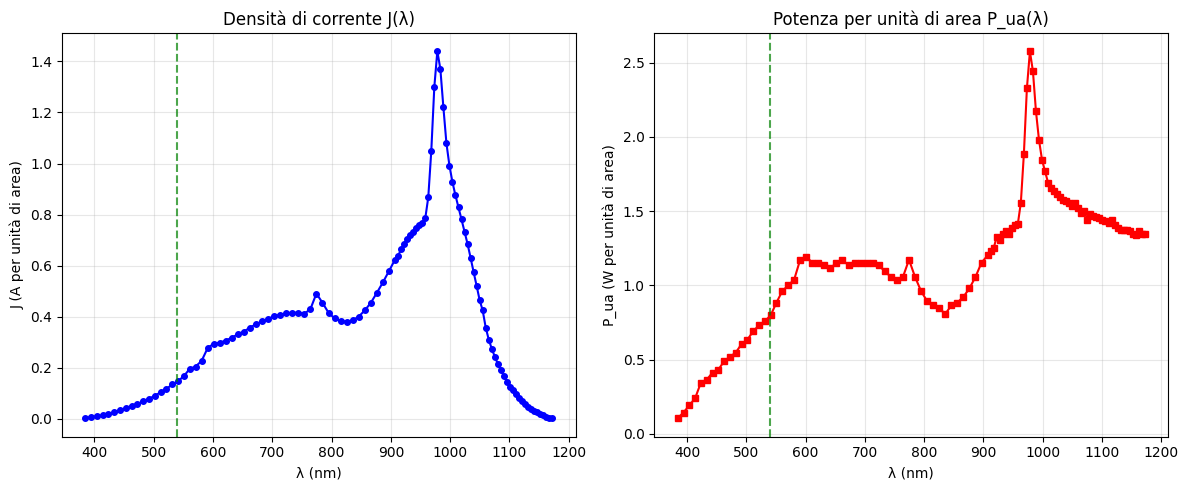

In [4]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df['lambda_nm'], df['J'], 'o-', color='blue', markersize=4, linewidth=1.5)
plt.errorbar(df['lambda_nm'], df['J'], yerr=df['J_err'],
             fmt='none', ecolor='blue', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('J (A per unità di area)')
plt.title('Densità di corrente J(λ)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7)

# Plot P_ua
plt.subplot(1, 2, 2)
plt.plot(df['lambda_nm'], df['P_ua'], 's-', color='red', markersize=4, linewidth=1.5)
plt.errorbar(df['lambda_nm'], df['P_ua'], yerr=df['P_ua_err'],
             fmt='none', ecolor='red', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('P_ua (W per unità di area)')
plt.title('Potenza per unità di area P_ua(λ)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

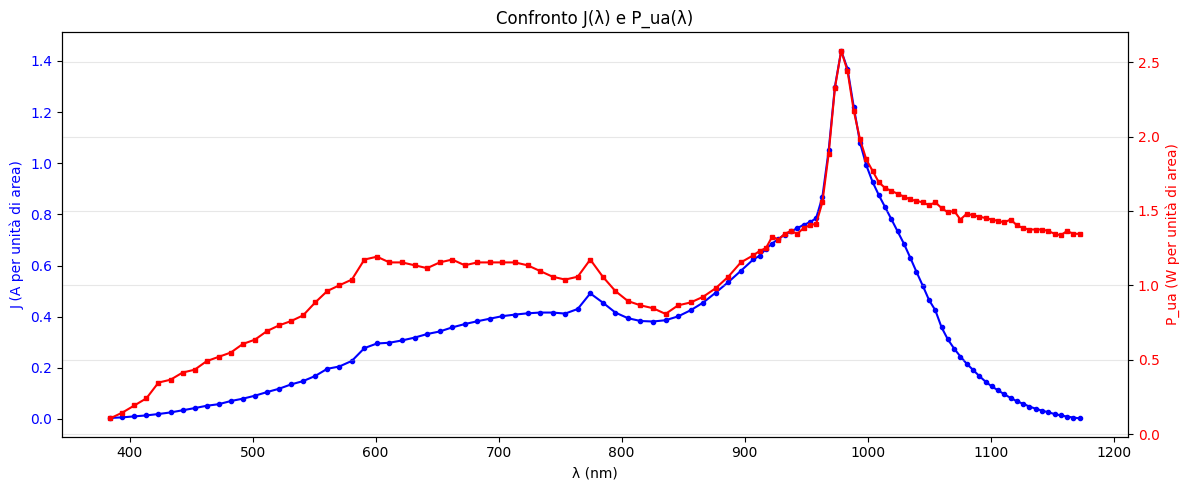

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('λ (nm)')
ax1.set_ylabel('J (A per unità di area)', color='blue')
ax1.plot(df['lambda_nm'], df['J'], 'o-', color='blue', markersize=3, label='J')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('P_ua (W per unità di area)', color='red')
ax2.plot(df['lambda_nm'], df['P_ua'], 's-', color='red', markersize=3, label='P_ua')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Confronto J(λ) e P_ua(λ)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Statistiche rapporto J/P_ua:
   Max = 0.5614
   Min = 0.0017
   Medio = 0.2972
   a λ_max = 988.7 nm


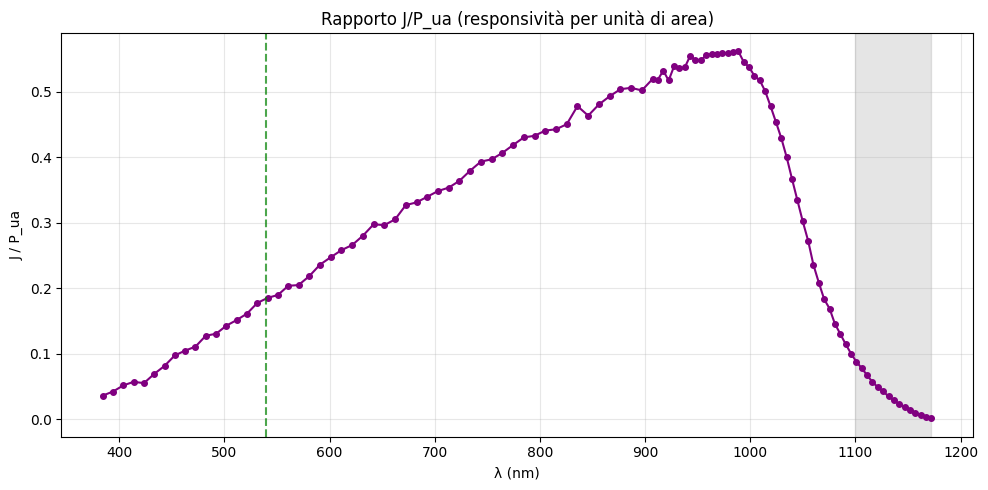

In [6]:

df['R'] = df['J'] / df['P_ua']
df['R_err'] = df['R'] * np.sqrt((df['J_err']/df['J'])**2 + (df['P_ua_err']/df['P_ua'])**2)

print(f"\nStatistiche rapporto J/P_ua:")
print(f"   Max = {df['R'].max():.4f}")
print(f"   Min = {df['R'].min():.4f}")
print(f"   Medio = {df['R'].mean():.4f}")
print(f"   a λ_max = {df.loc[df['R'].idxmax(), 'lambda_nm']:.1f} nm")

plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['R'], 'o-', color='purple', markersize=4, linewidth=1.5)
plt.errorbar(df['lambda_nm'], df['R'], yerr=df['R_err'],
             fmt='none', ecolor='purple', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('J / P_ua')
plt.title('Rapporto J/P_ua (responsività per unità di area)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7)
plt.axvspan(1100, df['lambda_nm'].max(), alpha=0.2, color='gray')
plt.tight_layout()
plt.show()

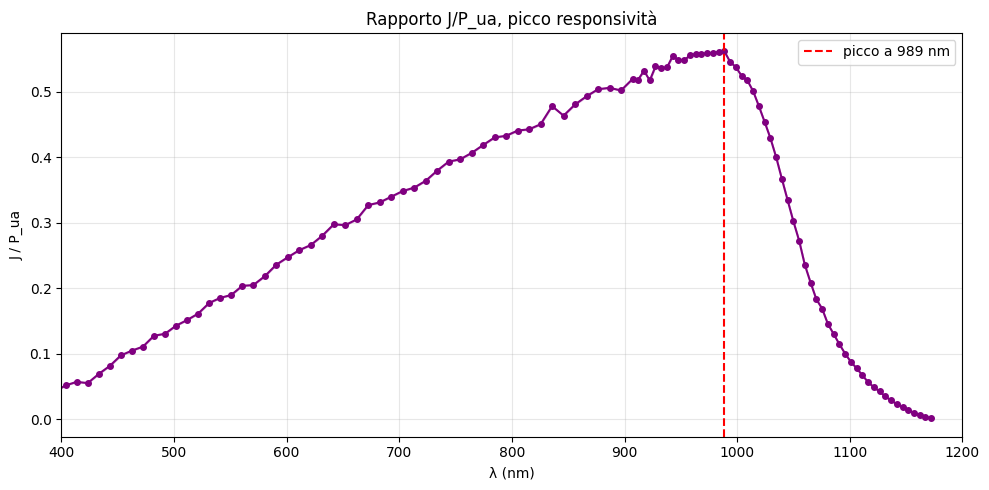

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['R'], 'o-', color='purple', markersize=4)
plt.fill_between(df['lambda_nm'], df['R'] - df['R_err'], df['R'] + df['R_err'],
                 alpha=0.2, color='purple')
plt.xlabel('λ (nm)')
plt.ylabel('J / P_ua')
plt.title('Rapporto J/P_ua, picco responsività')
plt.xlim(400, 1200)
plt.grid(True, alpha=0.3)
plt.axvline(x=df.loc[df['R'].idxmax(), 'lambda_nm'], color='red', linestyle='--',
            label=f"picco a {df.loc[df['R'].idxmax(), 'lambda_nm']:.0f} nm")
plt.legend()
plt.tight_layout()
plt.show()


Statistiche EQE:
   Max = 72.89 ± 0.05% a 942.8 nm
   Min = 0.18 ± 0.00% a 1172.3 nm
   Medio (pesato) = 1.60 ± 0.00%


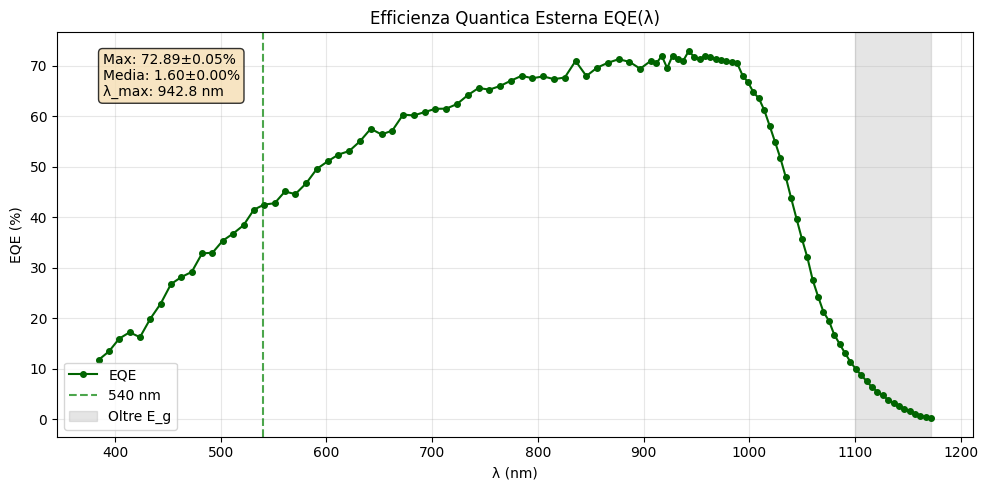

In [8]:


df['EQE'] = df['R'] * (1240 / df['lambda_nm'])
df['EQE_err'] = df['EQE'] * (df['R_err'] / df['R'])


idx_max = df['EQE'].idxmax()
lambda_max = df.loc[idx_max, 'lambda_nm']
EQE_max = df.loc[idx_max, 'EQE']
EQE_max_err = df.loc[idx_max, 'EQE_err']


idx_min = df['EQE'].idxmin()
lambda_min = df.loc[idx_min, 'lambda_nm']
EQE_min = df.loc[idx_min, 'EQE']
EQE_min_err = df.loc[idx_min, 'EQE_err']


w = 1 / df['EQE_err']**2
EQE_medio = np.sum(w * df['EQE']) / np.sum(w)
EQE_medio_err = 1 / np.sqrt(np.sum(w))

print(f"\nStatistiche EQE:")
print(f"   Max = {EQE_max*100:.2f} ± {EQE_max_err*100:.2f}% a {lambda_max:.1f} nm")
print(f"   Min = {EQE_min*100:.2f} ± {EQE_min_err*100:.2f}% a {lambda_min:.1f} nm")
print(f"   Medio (pesato) = {EQE_medio*100:.2f} ± {EQE_medio_err*100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(df['lambda_nm'], df['EQE']*100, 'o-', color='darkgreen', markersize=4, linewidth=1.5, label='EQE')
plt.errorbar(df['lambda_nm'], df['EQE']*100, yerr=df['EQE_err']*100,
             fmt='none', ecolor='darkgreen', alpha=0.5, capsize=2)
plt.xlabel('λ (nm)')
plt.ylabel('EQE (%)')
plt.title('Efficienza Quantica Esterna EQE(λ)')
plt.grid(True, alpha=0.3)
plt.axvline(x=540, color='green', linestyle='--', alpha=0.7, label='540 nm')
plt.axvspan(1100, df['lambda_nm'].max(), alpha=0.2, color='gray', label='Oltre E_g')

textstr = (f'Max: {EQE_max*100:.2f}±{EQE_max_err*100:.2f}%\n'
           f'Media: {EQE_medio*100:.2f}±{EQE_medio_err*100:.2f}%\n'
           f'λ_max: {lambda_max:.1f} nm')
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

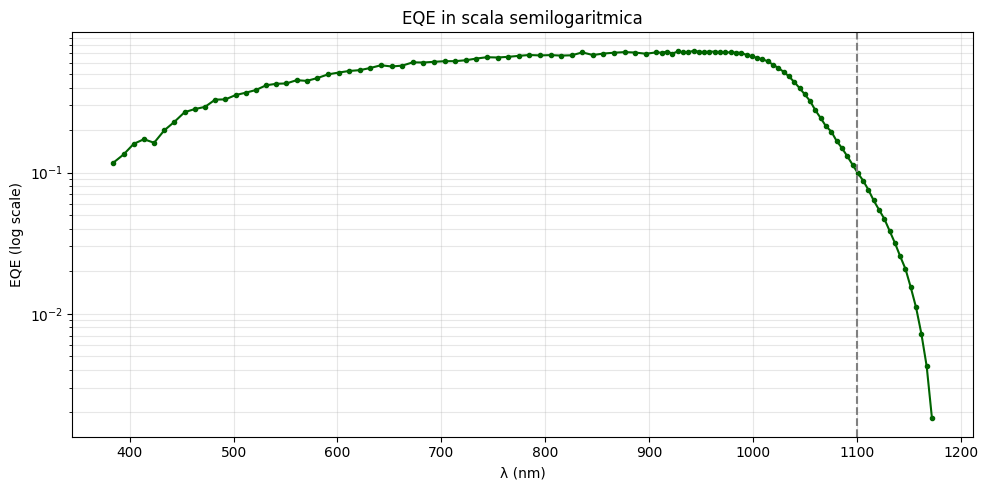

In [9]:
plt.figure(figsize=(10, 5))
plt.semilogy(df['lambda_nm'], df['EQE'], 'o-', color='darkgreen', markersize=3)
plt.xlabel('λ (nm)')
plt.ylabel('EQE (log scale)')
plt.title('EQE in scala semilogaritmica')
plt.grid(True, alpha=0.3, which='both')
plt.axvline(x=1100, color='gray', linestyle='--', label='λ_gap')
plt.tight_layout()
plt.show()

Dovrebbe essere silicio policristallino (da confermare se il fattore di idealità viene compreso tra 1.5 e 2)


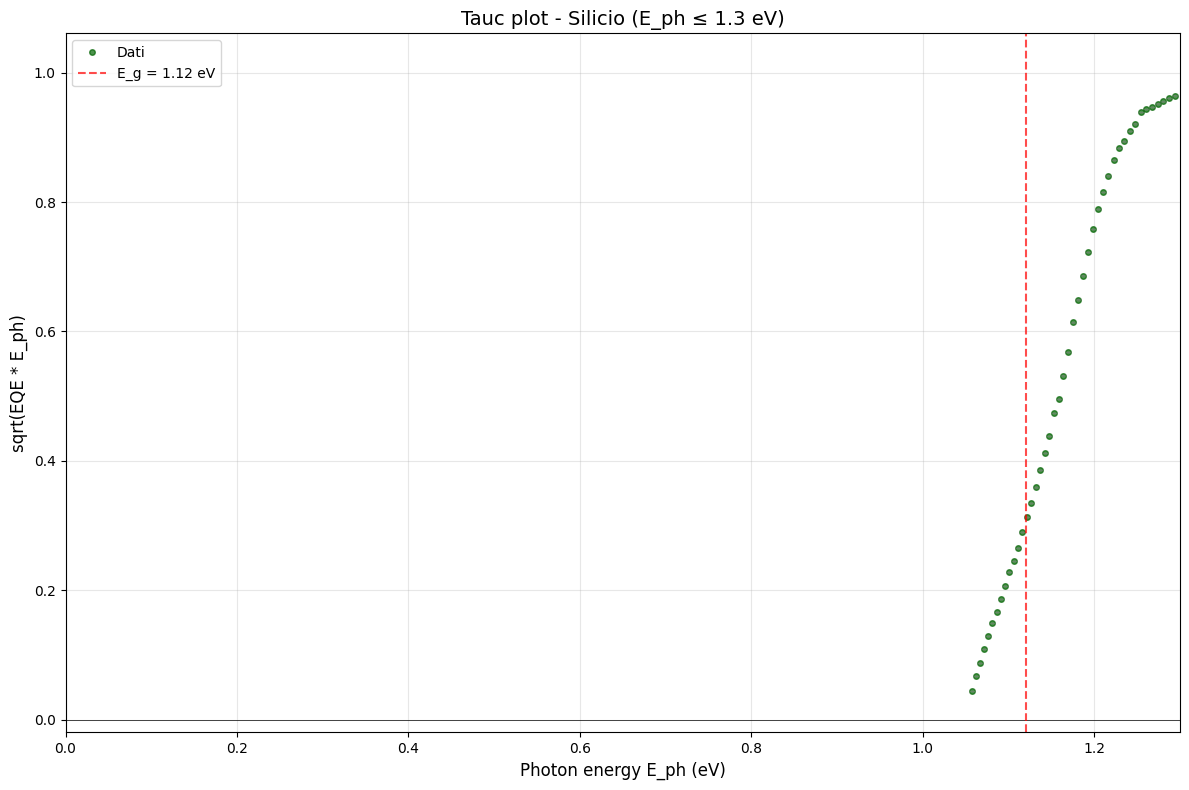

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df['E_ph'] = 1240 / df['lambda_nm']
df['Y_tauc'] = np.sqrt(df['EQE'] * df['E_ph'])
df['Y_tauc_err'] = 0.5 * df['Y_tauc'] * np.sqrt((df['EQE_err']/df['EQE'])**2 + (df['lambda_nm_err']/df['lambda_nm'])**2)

mask = df['E_ph'] <= 1.30
df_zoom = df[mask].copy()

plt.figure(figsize=(12, 8))

plt.plot(df_zoom['E_ph'], df_zoom['Y_tauc'], 'o', color='darkgreen',
         markersize=4, alpha=0.7, label='Dati')
plt.errorbar(df_zoom['E_ph'], df_zoom['Y_tauc'], yerr=df_zoom['Y_tauc_err'],
             fmt='none', ecolor='gray', alpha=0.3, capsize=2)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(1.12, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='E_g = 1.12 eV')

plt.xlabel('Photon energy E_ph (eV)', fontsize=12)
plt.ylabel('sqrt(EQE * E_ph)', fontsize=12)
plt.title('Tauc plot - Silicio (E_ph ≤ 1.3 eV)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.xlim(0, 1.30)
plt.ylim(-0.02, np.max(df_zoom['Y_tauc']) * 1.1)

plt.tight_layout()
plt.show()



Punto 1 (indice 0): E = 1.0577 eV, Y = 0.0438
Punto 19 (indice 18): E = 1.1476 eV, Y = 0.4383
Punto 29 (indice 28): E = 1.2045 eV, Y = 0.7890
   Pendenza m1 = 4.3897 +/- 0.0489
   Intercetta asse x: E1 = 1.0478 +/- 0.0166 eV
   Pendenza m2 = 6.1694 +/- 0.1087
   Intercetta asse x: E2 = 1.0766 +/- 0.0277 eV

Energia gap: Eg = (E1 + E2)/2 = 1.0622 +/- 0.0162 eV
Energia fonone: hw = (E2 - E1)/2 = 0.0144 +/- 0.0162 eV


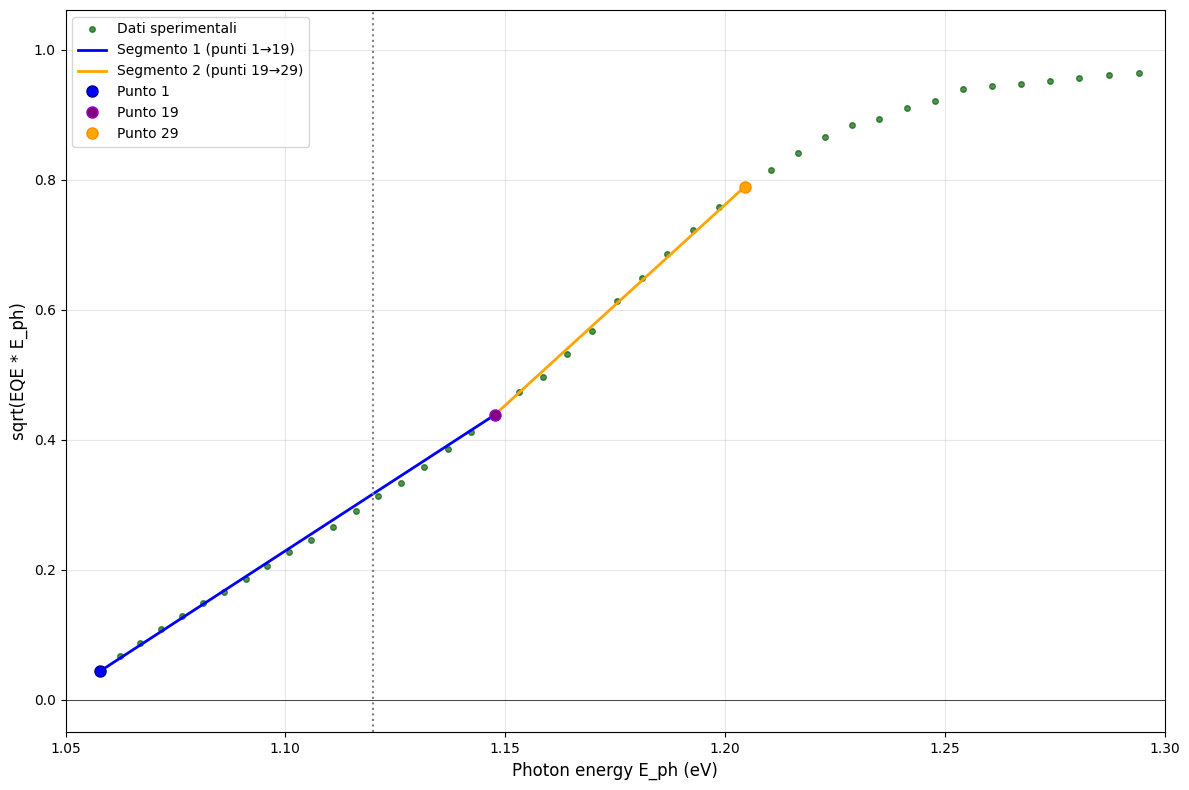

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df['E_ph'] = 1240 / df['lambda_nm']
df['Y_tauc'] = np.sqrt(df['EQE'] * df['E_ph'])
df['Y_tauc_err'] = 0.5 * df['Y_tauc'] * np.sqrt((df['EQE_err']/df['EQE'])**2 + (df['lambda_nm_err']/df['lambda_nm'])**2)

mask = df['E_ph'] <= 1.30
df_zoom = df[mask].copy().reset_index(drop=True)

df_zoom = df_zoom.sort_values('E_ph').reset_index(drop=True)

n_points = len(df_zoom)

idx1 = 0
idx2 = 18
idx3 = 28

print(f"\nPunto 1 (indice {idx1}): E = {df_zoom.iloc[idx1]['E_ph']:.4f} eV, Y = {df_zoom.iloc[idx1]['Y_tauc']:.4f}")
print(f"Punto {idx2+1} (indice {idx2}): E = {df_zoom.iloc[idx2]['E_ph']:.4f} eV, Y = {df_zoom.iloc[idx2]['Y_tauc']:.4f}")
print(f"Punto {idx3+1} (indice {idx3}): E = {df_zoom.iloc[idx3]['E_ph']:.4f} eV, Y = {df_zoom.iloc[idx3]['Y_tauc']:.4f}")

x1 = df_zoom.iloc[idx1]['E_ph']
y1 = df_zoom.iloc[idx1]['Y_tauc']
x2 = df_zoom.iloc[idx2]['E_ph']
y2 = df_zoom.iloc[idx2]['Y_tauc']
x3 = df_zoom.iloc[idx3]['E_ph']
y3 = df_zoom.iloc[idx3]['Y_tauc']

err_y1 = df_zoom.iloc[idx1]['Y_tauc_err']
err_y2 = df_zoom.iloc[idx2]['Y_tauc_err']
err_y3 = df_zoom.iloc[idx3]['Y_tauc_err']

m1 = (y2 - y1) / (x2 - x1)
err_m1 = m1 * np.sqrt((err_y1/(y2-y1))**2 + (err_y2/(y2-y1))**2 + (0.001/(x2-x1))**2)

b1 = y1 - m1 * x1
err_b1 = np.sqrt(err_y1**2 + (x1 * err_m1)**2 + (m1 * 0.001)**2)
E1 = -b1 / m1
err_E1 = E1 * np.sqrt((err_b1/b1)**2 + (err_m1/m1)**2)

m2 = (y3 - y2) / (x3 - x2)
err_m2 = m2 * np.sqrt((err_y2/(y3-y2))**2 + (err_y3/(y3-y2))**2 + (0.001/(x3-x2))**2)

b2 = y2 - m2 * x2
err_b2 = np.sqrt(err_y2**2 + (x2 * err_m2)**2 + (m2 * 0.001)**2)
E2 = -b2 / m2
err_E2 = E2 * np.sqrt((err_b2/b2)**2 + (err_m2/m2)**2)

Eg = (E1 + E2) / 2
err_Eg = np.sqrt(err_E1**2 + err_E2**2) / 2

hw = (E2 - E1) / 2
err_hw = np.sqrt(err_E1**2 + err_E2**2) / 2


print(f"   Pendenza m1 = {m1:.4f} +/- {err_m1:.4f}")
print(f"   Intercetta asse x: E1 = {E1:.4f} +/- {err_E1:.4f} eV")
print(f"   Pendenza m2 = {m2:.4f} +/- {err_m2:.4f}")
print(f"   Intercetta asse x: E2 = {E2:.4f} +/- {err_E2:.4f} eV")
print(f"\nEnergia gap: Eg = (E1 + E2)/2 = {Eg:.4f} +/- {err_Eg:.4f} eV")
print(f"Energia fonone: hw = (E2 - E1)/2 = {hw:.4f} +/- {err_hw:.4f} eV")

plt.figure(figsize=(12, 8))

plt.plot(df_zoom['E_ph'], df_zoom['Y_tauc'], 'o', color='darkgreen',
         markersize=4, alpha=0.7, label='Dati sperimentali')
plt.errorbar(df_zoom['E_ph'], df_zoom['Y_tauc'], yerr=df_zoom['Y_tauc_err'],
             fmt='none', ecolor='gray', alpha=0.3, capsize=2)

E_seg1 = np.linspace(x1, x2, 100)
Y_seg1 = m1 * E_seg1 + b1
plt.plot(E_seg1, Y_seg1, '-', color='blue', linewidth=2, label=f'Segmento 1 (punti 1→{idx2+1})')

E_seg2 = np.linspace(x2, x3, 100)
Y_seg2 = m2 * E_seg2 + b2
plt.plot(E_seg2, Y_seg2, '-', color='orange', linewidth=2, label=f'Segmento 2 (punti {idx2+1}→{idx3+1})')

plt.plot([x1], [y1], 'o', color='blue', markersize=8, markeredgecolor='darkblue', label='Punto 1')
plt.plot([x2], [y2], 'o', color='purple', markersize=8, markeredgecolor='darkviolet', label=f'Punto {idx2+1}')
plt.plot([x3], [y3], 'o', color='orange', markersize=8, markeredgecolor='darkorange', label=f'Punto {idx3+1}')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(1.12, color='gray', linestyle=':', linewidth=1.5)

plt.xlabel('Photon energy E_ph (eV)', fontsize=12)
plt.ylabel('sqrt(EQE * E_ph)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.xlim(1.05, 1.30)
plt.ylim(-0.05, np.max(df_zoom['Y_tauc']) * 1.1)

plt.tight_layout()
plt.show()
